In [1]:
import numpy as np
import pandas as pd

### Basic Data Structure In Pandas
Two types of classes for handling data:
- Series (integers, strings, Python Object)
- DataFrame

### Object creation

Creating a Series by passing a list of values, letting pandas create a default RangeIndex.

In [ ]:
s =  pd.Series([1, 3, 5, np.nan, 6, 8])
print(s)

Creating a DataFrame by passing a NumPy array with a datetime index using date_range() and labeled columns:

In [ ]:
dates = pd.date_range("20260512", periods=8)
dates

df = pd.DataFrame(np.random.randn(8, 4), index=dates, columns=list('ABCD'))
print(f'\n{df}')

Creating a DataFrame by passing a dictionary of objects where the keys are the column labels and the values are the column values.

In [ ]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20260513"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "tuat", "train"]),
        "F": "foo",
    }
)
df2

In [ ]:
df2.dtypes

### Viewing Data

In [ ]:
df.head()

In [ ]:
df.tail(3)

In [ ]:
df.index

In [ ]:
df.columns

Return a NumPy representation of the underlying data with DataFrame.to_numpy() without the index or column labels

In [ ]:
result = df.to_numpy()
print(type(result))
print(result.shape)
print(result)

describe() shows a quick statistic summary of your data

In [ ]:
df.describe()

Transposing your data

In [ ]:
df.T

DataFrame.sort_index() sorts by an axis

In [ ]:
df.sort_index(axis=1, ascending=False)

DataFrame.sort_values() sorts by values

In [ ]:
df.sort_values(by="A")

### Getitem

For a DataFrame, passing a single label selects a column and yields a Series

In [ ]:
df["A"]

If the label only contains letters, numbers, and underscores, you can alternatively use the column name attribute

In [ ]:
df.A

Passing a list of column labels selects multiple columns, which can be useful for getting a subset/rearranging

In [ ]:
df[["B", "D"]]

For a DataFrame, passing a slice : selects matching rows

In [ ]:
df[0:3]

### Selection By Label

Selecting a row matching a label

In [ ]:
df.loc[dates[0]]

Selecting all rows (:) with a select column labels

In [ ]:
df.loc[:, ["A", "C"]]

For label slicing, both endpoints are included

In [ ]:
df.loc["20260514":"20260517", ["A", "B"]]

Selecting a single row and column label returns a scalar

In [ ]:
df.loc[dates[0], "A"]

For getting fast access to a scalar (equivalent to the prior method)

In [ ]:
df.at[dates[0], "A"]

### Selection By Position

Select via the position of the passed integers

In [ ]:
df.iloc[3]

Integer slices acts similar to NumPy/Python

In [ ]:
df.iloc[3:5, 0:2]

Lists of integer position locations

In [ ]:
df.iloc[[1, 2, 4], [0,3]]

For slicing rows explicitly

In [ ]:
df.iloc[1:3, :]

For slicing columns explicitly

In [ ]:
df.iloc[:, 1:3]

For getting a value explicitly

In [ ]:
df.iloc[1, 1]

For getting fast access to a scalar (equivalent to the prior method)

In [ ]:
df.iat[1, 1]

### Boolean Indexing

Select rows where df.A is greater than 0

In [ ]:
df[df["A"] > 0]

Selecting values from a DataFrame where a boolean condition is met

In [ ]:
df[df> 0]

Using isin() method for filtering

In [ ]:
df2 = df.copy()
df2["E"] = ["Anna", "Emma", "Herry", "Nova", "Thomas", "Timi", "Sona", "Titan"]
df2

In [ ]:
df2[df2["E"].isin(["Anna", "Emma", "Herry"])]

### Setting

Setting a new column automatically aligns the data by the indexes

In [ ]:
s1 = pd.Series(
    [1, 2, 3, 4, 5, 6],
    index=pd.date_range("20260513", periods=6),
)
s1
df["F"] = s1
df

Setting values by label

In [ ]:
df.at[dates[0], "A"] = 0

Setting values by position

In [ ]:
df.iat[0, 1] = 0

Setting by assigning with a NumPy array

In [ ]:
df.loc[:, "D"] = np.array([5] * len(df))
df

In [ ]:
df2 = df.copy()
df2[df2 > 0] = -df2
df2

### Missing Data

Reindexing allows you to change/add/delete the index on a specified axis. This returns a copy of the data

In [ ]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])
df1.loc[dates[0] : dates[1], "E"] = 1
df1

DataFrame.dropna() drops any rows that have missing data

In [ ]:
df1.dropna(how="any")

DataFrame.fillna() fills missing data

In [ ]:
df1.fillna(value=5)

isna() gets the boolean mask where values are nan

In [ ]:
pd.isna(df1)

### Operations

#### Stats

Calculate the mean value for each column

In [ ]:
df.mean()

Calculate the mean value for each row

In [ ]:
df.mean(axis=1)

In [ ]:
s = pd.Series([1, 3, 5, np.nan, 6, 8, 9, 4], index=dates).shift(2)
s
df.sub(s, axis="index")

#### User defined function

In [ ]:
df.agg(lambda x: np.mean(x) * 5.6)
df.transform(lambda x: x * 101.2)

#### Value counts

In [ ]:
s = pd.Series(np.random.randint(0, 7, size=10))
s
s.value_counts()

#### String methods

In [ ]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])
s.str.lower()

### Merge

#### Concat

In [ ]:
df = pd.DataFrame(np.random.randn(10, 4))
df

pieces = [df[:3], df[3:7], df[7:]]
pd.concat(pieces)

#### Join

In [ ]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
left
right

pd.merge(left, right, on="key")

merge() on unique keys

In [ ]:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})
left
right
pd.merge(left, right, on="key")

### Grouping

In [ ]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
df

Grouping by a column label, selecting column labels, and then applying the DataFrameGroupBy.sum() function to the resulting groups

In [ ]:
df.groupby("A")[["C", "D"]].sum()

Grouping by multiple columns label forms MultiIndex

In [ ]:
df.groupby(["A", "B"]).sum()

### Reshaping

#### Stack

In [ ]:
arrays = [
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])
df2 = df[:4]
df

The stack() method “compresses” a level in the DataFrame’s columns

In [ ]:
stacked = df2.stack()
stacked

In [ ]:
stacked.unstack()
stacked.unstack(1)
stacked.unstack(0)

#### Pivot tables

In [ ]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
df

pivot_table() pivots a DataFrame specifying the values, index and columns

In [ ]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

### Time Series

In [ ]:
rng = pd.date_range("1/1/2012", periods=100, freq="s")
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts.resample("5Min").sum()

Series.tz_localize() localizes a time series to a time zone

In [ ]:
rng = pd.date_range("3/6/2012 00:00", periods=5, freq="D")
ts = pd.Series(np.random.randn(len(rng)), rng)
ts

ts_utc = ts.tz_localize("UTC")
ts_utc

Series.tz_convert() converts a timezones aware time series to another time zone

In [ ]:
ts_utc.tz_convert("US/Eastern")

Adding a non-fixed duration (BusinessDay) to a time series

In [ ]:
rng
rng + pd.offsets.BusinessDay(5)

### Categoricals

In [24]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)

Converting the raw grades to a categorical data type

In [30]:
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, str): ['a', 'b', 'e']

Rename the categories to more meaningful names

In [31]:
new_categories = ["very good", "good", "very bad"]
df["grade"] = df["grade"].cat.rename_categories(new_categories)

In [32]:
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)
df["grade"]

0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (5, str): ['very bad', 'bad', 'medium', 'good', 'very good']

Sorting is per order in the categories, not lexical order

In [33]:
df.sort_values(by="grade")

,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


Grouping by a categorical column with observed=False also shows empty categories

In [34]:
df.groupby("grade", observed=False).size()

grade
very bad     1
bad          0
medium       0
good         2
very good    3
dtype: int64

### Plotting

In [35]:
import matplotlib.pyplot as plt
plt.close("all")

The plt.close method is used to close a figure window

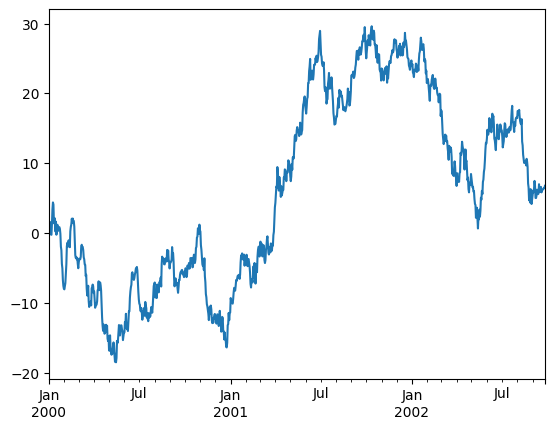

In [36]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))
ts = ts.cumsum()
ts.plot();

plot() plots all columns

<Figure size 640x480 with 0 Axes>

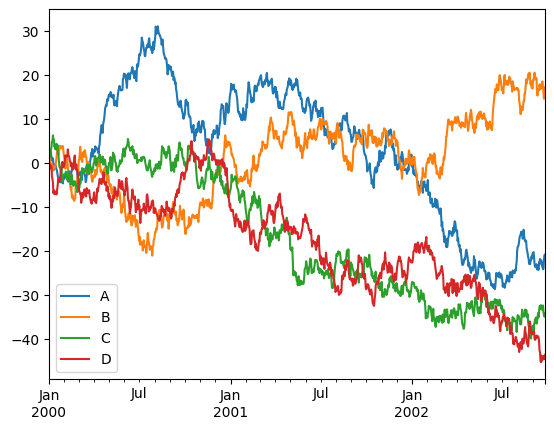

In [37]:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)
df = df.cumsum()
plt.figure();
df.plot();
plt.legend(loc='best');

### Importing and exporting data

#### CSV

In [4]:
df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))
df.to_csv("foo.csv")

In [39]:
pd.read_csv("foo.csv")

,Unnamed: 0,0,1,2,3,4
0,0,3,3,0,1,2
1,1,1,0,2,3,0
2,2,3,2,4,3,1
3,3,3,2,4,0,3
4,4,1,0,0,2,4
5,5,1,0,4,1,2
6,6,0,2,1,4,2
7,7,4,4,3,0,2
8,8,0,2,4,3,2
9,9,1,0,3,1,1


#### Parquet

Writing to a Parquet file

In [6]:
df.to_parquet("foo.parquet")
pd.read_parquet("foo.parquet")

,0,1,2,3,4
0,1,2,3,2,3
1,2,4,0,3,4
2,4,4,2,1,3
3,0,2,2,0,4
4,0,0,4,0,1
5,0,3,4,0,0
6,2,3,4,3,3
7,4,3,3,2,1
8,1,1,0,0,2
9,2,4,4,1,4


#### Excel

Writing to an excel file using DataFrame.to_excel()

In [8]:
df.to_excel("foo.xlsx", sheet_name="Sheet1")

Reading from an excel file using read_excel()

In [9]:
pd.read_excel("foo.xlsx", "Sheet1", index_col=None, na_values=["NA"])

,Unnamed: 0,0,1,2,3,4
0,0,1,2,3,2,3
1,1,2,4,0,3,4
2,2,4,4,2,1,3
3,3,0,2,2,0,4
4,4,0,0,4,0,1
5,5,0,3,4,0,0
6,6,2,3,4,3,3
7,7,4,3,3,2,1
8,8,1,1,0,0,2
9,9,2,4,4,1,4
